# Problem Definition

Our problem can be formulated as a capacitated vehicle routing problem with a single depot, fixed pickup locations, and time-windowed drop-offs. The road network and stop set are given and are not decision variables. Edge travel times are fixed and do not depend on traffic. Consequently, the relevant temporal constraints concern (i) in-vehicle times experienced by students and (ii) arrival deadlines at schools. A fleet of buses, each with fixed passenger capacity and a finite distance-based range (no refueling during operations), departs from and returns to a common depot (currently a single depot, with a possible extension to multiple depots). Students wait at designated stops and must be delivered to their assigned school no later than a specified slack $\delta$ before that school's start time. Additionally, each student must spend at most $1\,\mathrm{h}$ inside a bus. Capacity constraints apply only at the bus level. Furthermore, service times are modeled explicitly as each boarding event incurs a fixed dwell time of $0.3$ minutes per student, and each alighting event at a school incurs $0.5$ minutes per student. Buses are not dedicated to a particular school and may serve multiple schools on a single tour, provided that all students are delivered to their own school and no inter-bus transfers are permitted. A subset of students is flagged as requiring additional on-board support which is provided by a \emph{monitor} who is themselves a staff member riding to school. Feasibility requires that the monitor be picked up prior to the first boarding of any flagged student.

To simplify the routing problem, we do not consider for the pickup students that live within a certain distance $\gamma$ from their school. Furthermore, we reduce the real-world street graph to reflect only the shortest paths between the depot, schools, and stops.

In [41]:
import networkx as nx
import matplotlib.pyplot as plt
import cvxpy as cp
import random

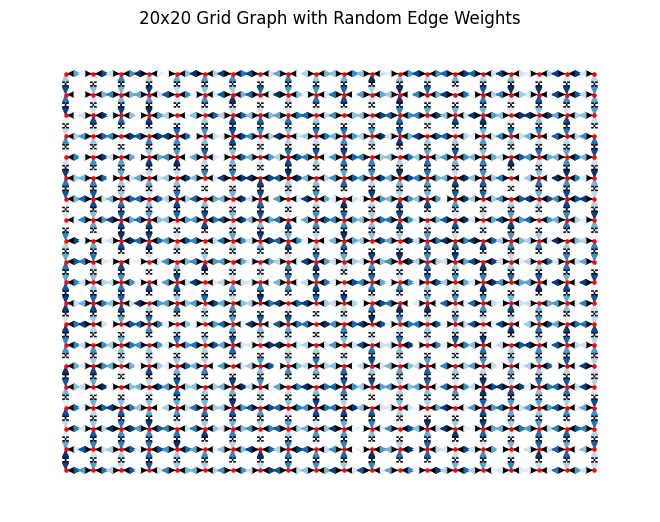

In [42]:
# set up a 20 x 20 grid graph
G: nx.Graph = nx.grid_2d_graph(20, 20, create_using=nx.DiGraph)

# assign random weights to the edges
for (u, v) in G.edges():
    G.edges[u, v]['weight'] = random.randint(1, 20)

# visualize the graph
pos = {(x, y): (x, y) for x, y in G.nodes()}
weights = nx.get_edge_attributes(G, 'weight')

nx.draw(G, pos, with_labels=False, node_size=5, node_color='red')
# color edges by weight
nx.draw_networkx_edges(G, pos, edge_color=list(weights.values()), edge_cmap=plt.cm.Blues)

plt.title("20x20 Grid Graph with Random Edge Weights")
plt.show()

In [43]:
from attr import dataclass
from enum import Enum

class SchoolType(Enum):
    NONE = 0,
    ELEMENTARY = 1,
    MIDDLE = 2,
    HIGH = 3

@dataclass(frozen=True)
class Stop:
    name: str
    location: tuple[float, float]

@dataclass(frozen=True)
class Depot:
    name: str
    location: tuple[float, float]

@dataclass(frozen=True)
class School:
    name: str
    location: tuple[float, float]
    type: SchoolType
    start_time: int  # in minutes from midnight

@dataclass(frozen=True)
class Bus:
    id: int
    capacity: int
    range: int
    has_wheelchair_access: bool
    depot: Depot

@dataclass(frozen=True)
class Student:
    name: str
    home_location: tuple[float, float]
    school: School
    stop: Stop
    requires_monitor: bool
    requires_wheelchair: bool

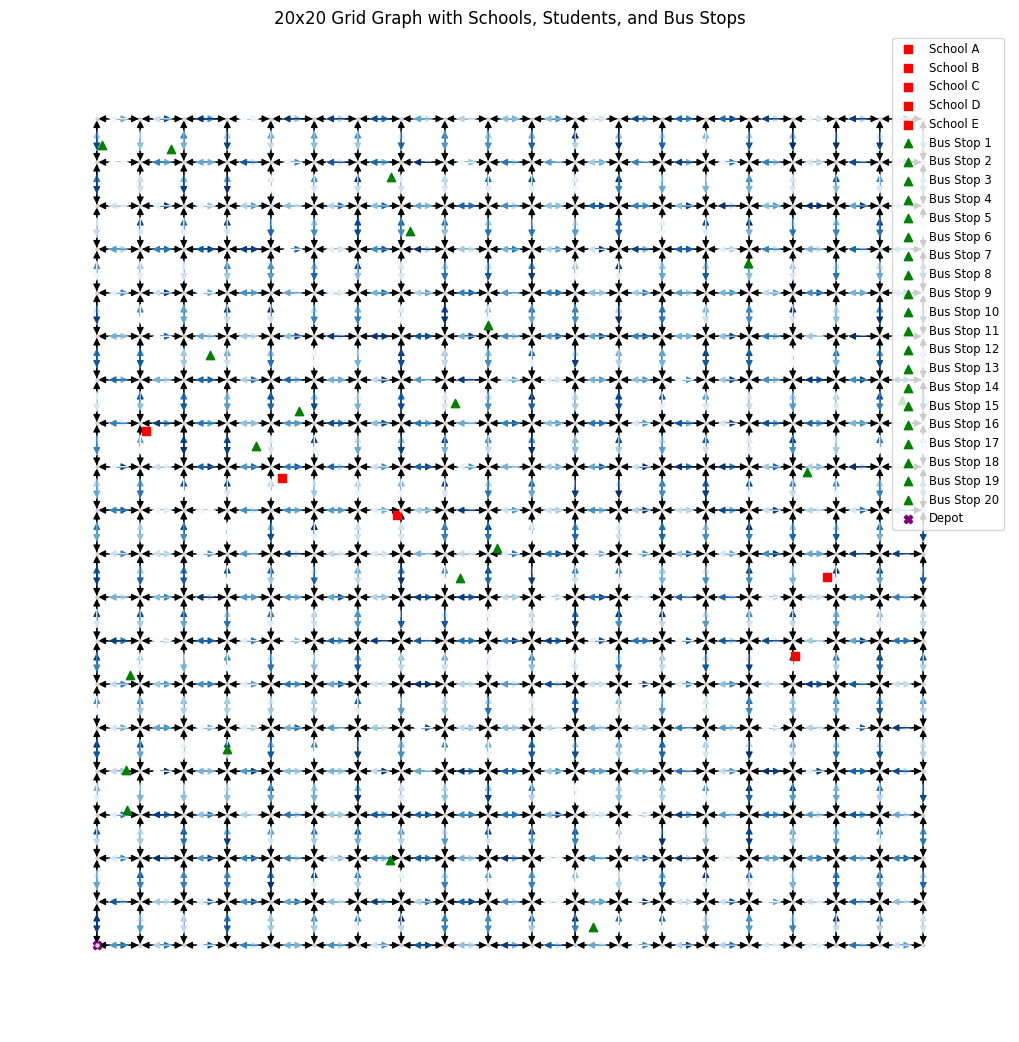

In [44]:
# add 5 schools at random positions, each either elementary, middle, or high school
school_names = ['School A', 'School B', 'School C', 'School D', 'School E']
school_types = [SchoolType.ELEMENTARY, SchoolType.MIDDLE, SchoolType.HIGH]
schools: list[School] = []
for i in range(5):
    school = School(
        name=school_names[i],
        location=(random.random() * 19, random.random() * 19),
        type=random.choice(school_types),
        start_time=random.randint(7 * 60, 9 * 60)  # schools start between 7 and 9 AM in minutes from midnight
    )
    schools.append(school)

# add 20 bus stops at random positions
bus_stops: list[Stop] = []
for i in range(20):
    x = random.random() * 19
    y = random.random() * 19
    bus_stops.append(Stop(name=f'Bus Stop {i+1}', location=(x, y)))

# depots
depots: list[Depot] = [Depot(name='Depot', location=(0, 0))]

# visualize the graph with schools, students, and bus stops
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=False, node_size=5, node_color='lightgray')
# color edges by weight
nx.draw_networkx_edges(G, pos, edge_color=list(weights.values()), edge_cmap=plt.cm.Blues)
# plot schools, students, and bus stops
for school in schools:
    plt.scatter(school.location[0], school.location[1], c='red', marker='s', label=school.name)
# for student in students:
#     plt.scatter(student.home_location[0], student.home_location[1], c='blue', marker='o', label=student.name)
for bus_stop in bus_stops:
    plt.scatter(bus_stop.location[0], bus_stop.location[1], c='green', marker='^', label=bus_stop.name)
for depot in depots:
    plt.scatter(depot.location[0], depot.location[1], c='purple', marker='X', label=depot.name)

plt.title("20x20 Grid Graph with Schools, Students, and Bus Stops")
plt.legend(loc='upper right', fontsize='small')
plt.show()

In [45]:
buses = []
for i in range(3):
    bus = Bus(
        id=i+1,
        capacity=8,
        range=30,
        # ensure at least one bus has wheelchair access
        has_wheelchair_access=(True if i == 0 else False),
        depot=random.choice(depots)
    )
    buses.append(bus)

def get_nearest_stop(location: tuple[float, float], stops: list[Stop]):
    min_distance = float('inf')
    nearest_stop = None
    for stop in stops:
        distance = ((location[0] - stop.location[0]) ** 2 + (location[1] - stop.location[1]) ** 2) ** 0.5
        if distance < min_distance:
            min_distance = distance
            nearest_stop = stop
    return nearest_stop

# add 10 students at random positions, going to random schools
student_names = ['Student 1', 'Student 2', 'Student 3', 'Student 4', 'Student 5',
                'Student 6', 'Student 7', 'Student 8', 'Student 9', 'Student 10']
students: list[Student] = []
for student_name in student_names:
    location = (random.random() * 19, random.random() * 19)
    student = Student(
        name=student_name,
        home_location=location,
        school=random.choice(schools),
        stop=get_nearest_stop(location, bus_stops),
        requires_monitor=random.choice([True, False, False, False, False]),  # some students require monitoring
        requires_wheelchair=random.choice([True, False, False, False, False])  # some students require wheelchair accessibility
    )
    students.append(student)  # store the student object for later reference

In [47]:
# CONSTANTS

# boarding dwell time per student
ALPHA = 0.3

# alighting dwell time per student
BETA = 0.5

# max ride time in minutes
H_RIDE = 60

# ratio of students served
PHI = 1.0

# non-negative time separation used for precedence
EPSILON = 1e-5

# capacity multiplier for different school types
C = {
    SchoolType.ELEMENTARY: 1.0,
    SchoolType.MIDDLE: 0.8,
    SchoolType.HIGH: 0.6
}

# big-M for time linking
M_TIME = 1000 # could be more accurate but thats later ig

# big-M for capacity linking
M_CAPACITY = 1000 # could be more accurate but thats later ig

# big-M for school type linking
M_TYPE = SchoolType.HIGH.value + 1 

In [37]:
P = [] # pickup stop nodes

S = [] # school nodes
S_PLUS = [] # school start-copy nodes

D = [] # depot nodes
D_PLUS = [] # depot start-copy nodes
D_MINUS = [] # depot end-copy nodes

for bus_stop in bus_stops:
    nearest_node = (round(bus_stop.location[0]), round(bus_stop.location[1]))
    P.append((nearest_node, bus_stop))

for school in schools:
    nearest_node = (round(school.location[0]), round(school.location[1]))
    S.append((nearest_node, school))
    S_PLUS.append((nearest_node, school))

for depot in depots:
    nearest_node = (round(depot.location[0]), round(depot.location[1]))
    D.append((nearest_node, depot))
    D_PLUS.append((nearest_node, depot))
    D_MINUS.append((nearest_node, depot))

N = P + S + D_PLUS + D_MINUS + S_PLUS

# Directed arcs on the service graph between service nodes. 
A = {}
for (node, _) in N:
    if not A.get(node):
        A[node] = {}
    for neighbor in G.neighbors(node):
        if not A.get(neighbor):
            A[neighbor] = {}
        A[node][neighbor] = nx.shortest_path(G, source=node, target=neighbor, weight='weight')
        A[neighbor][node] = nx.shortest_path(G, source=neighbor, target=node, weight='weight')

B = buses

M = students

# students needing monitor, eg special education or wheelchair
F = list(filter(lambda s: s.requires_monitor or s.requires_wheelchair, M))

# students requiring wheelchair access
W = list(filter(lambda s: s.requires_wheelchair, F))

# rounds a bus is allowed to have
Q = range(3)

In [ ]:
import cvxpy

constraints: list[cvxpy.Constraint] = []
# TODO: add constraints here